In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load Dataset
df = pd.read_csv("../data/processed/02_nav_history_clean.csv")

In [3]:
# Convert Date
df["date"] = pd.to_datetime(df["date"])

In [4]:
# Sort Data
df = df.sort_values(["amfi_code", "date"])

In [5]:
# Calculate Maximum Drawdown
results = []

for amfi_code, group in df.groupby("amfi_code"):

    group = group.copy()

    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = (
        group["nav"] / group["running_max"]
    ) - 1

    # Maximum drawdown row
    worst_row = group.loc[group["drawdown"].idxmin()]

    # Peak before worst drawdown
    peak_rows = group[group["date"] <= worst_row["date"]]
    peak_row = peak_rows.loc[peak_rows["nav"].idxmax()]

    results.append({
        "amfi_code": amfi_code,
        "Maximum_Drawdown": worst_row["drawdown"],
        "Peak_Date": peak_row["date"],
        "Worst_Drawdown_Date": worst_row["date"]
    })

drawdown_df = pd.DataFrame(results)

In [6]:
# Rank Funds
drawdown_df = drawdown_df.sort_values(
    by="Maximum_Drawdown"
)

print(drawdown_df.head())

    amfi_code  Maximum_Drawdown  Peak_Date Worst_Drawdown_Date
22     119599         -0.525742 2023-01-17          2025-10-28
17     119095         -0.516778 2025-05-22          2026-05-11
4      101207         -0.354469 2024-11-21          2026-05-11
39     149324         -0.311719 2024-05-03          2025-01-03
21     119598         -0.287060 2024-08-28          2025-05-14


In [7]:
# Save CSV
drawdown_df.to_csv(
    "../data/processed/maximum_drawdown_analysis.csv",
    index=False
)

print("Maximum Drawdown analysis saved successfully!")

Maximum Drawdown analysis saved successfully!


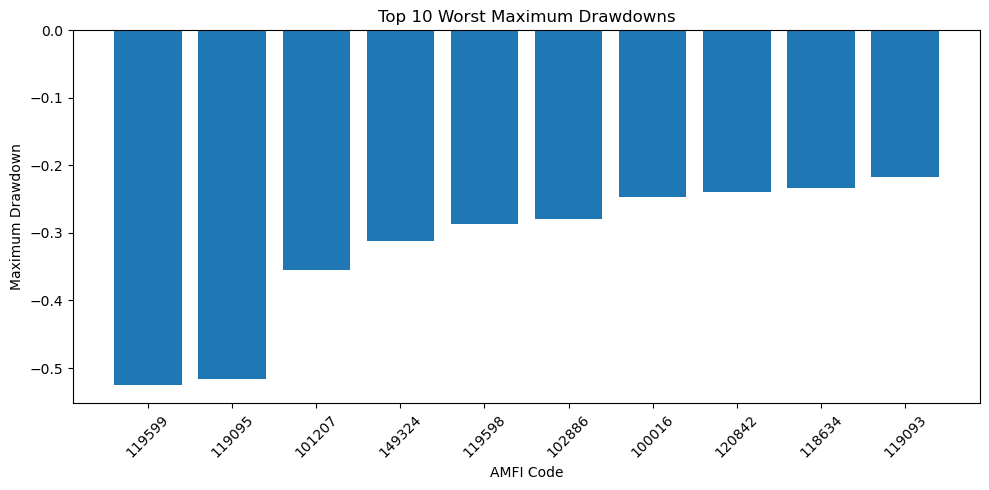

In [8]:
# Top 10 Worst Drawdowns Chart
top10 = drawdown_df.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["Maximum_Drawdown"]
)

plt.xticks(rotation=45)

plt.xlabel("AMFI Code")
plt.ylabel("Maximum Drawdown")
plt.title("Top 10 Worst Maximum Drawdowns")

plt.tight_layout()

plt.savefig("../reports/20_maximum_drawdown.png")

plt.show()

In [9]:
## Insight

# Maximum Drawdown measures the largest percentage decline from a fund's previous peak NAV. The analysis identifies the worst drawdown for each mutual fund along with the corresponding peak date and drawdown date, helping evaluate downside risk and recovery potential.